# Обработка изображений с использованием numpy

**Цель работы:** Закрепить навыки работы с NumPy через реализацию базовых фильтров и преобразований изображений вручную, без библиотек компьютерного зрения.

**Что изучается в этой работе:**

- чтение и представление изображения как массива NumPy
- фильтры: размытие, Sharpen, детектор границ
- свёртка (convolution) руками
- бинаризация
- работа с каналами RGB
- изменение яркости/контраста
- различные фильтры

In [ ]:
# импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### Загрузка изображения

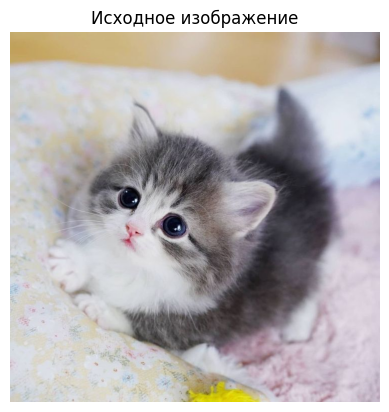

In [ ]:
# загрузка изображения
img = Image.open("kitten_test.jpg")
img = np.array(img)

plt.imshow(img)
plt.title("Исходное изображение")
plt.axis('off')
plt.show()

In [ ]:
print('Размер массива:', img.shape)  # (высота, ширина, каналы)
print('Тип файла:', img.dtype)  # uint8

Размер массива: (736, 736, 3)
Тип файла: uint8


### Перевод в ЧБ

Градации серого — это яркость, а яркость складывается из R, G и B не одинаково.

Веса перевода RGB -> Grayscale такие:

0.299 — вклад красного канала

0.587 — вклад зелёного канала

0.114 — вклад синего

Это официальная формула из стандарта ITU-R BT.601.

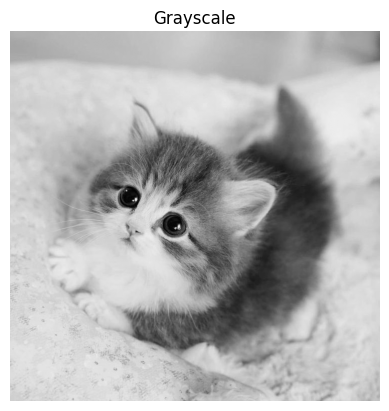

In [ ]:
gray = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
gray = gray.astype(np.uint8)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

### Реализация свертки вручную

In [ ]:
def convolve2d(image, kernel):
    # Получение размеров изображения и ядра
    H, W = image.shape
    kH, kW = kernel.shape

    # Паддинг изображения
    pad_h = kH // 2
    pad_w = kW // 2

    # Добавление паддинга к изображению
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')

    # Создание выходного массива
    output = np.zeros((H, W))
    
    # Выполнение свертки
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kH, j:j+kW]
            output[i, j] = np.sum(region * kernel)
    
    return output

#### Фильтр блюра

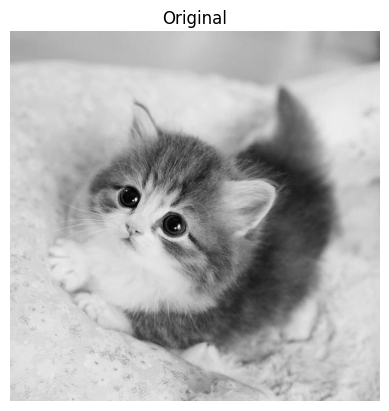

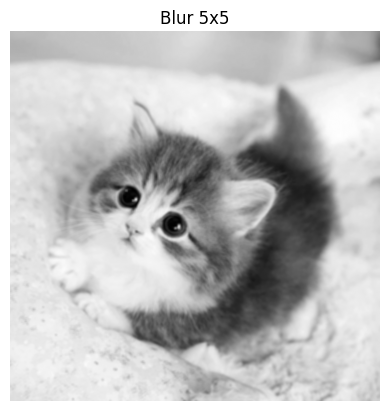

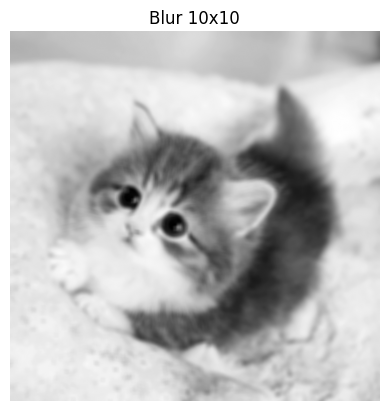

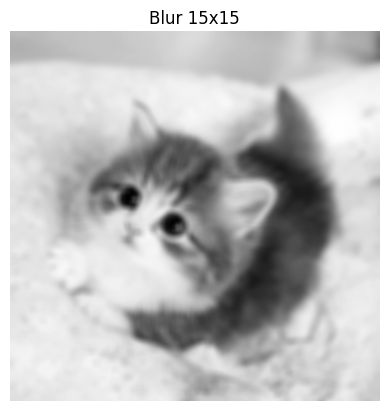

In [ ]:
# Фильтр блюра
blur_kernel_5 = np.ones((5,5)) / 25
blur_kernel_10 = np.ones((10,10)) / 100
blur_kernel_15 = np.ones((15,15)) / 225

# Применение свертки
blurred_5 = convolve2d(gray, blur_kernel_5)
blurred_10 = convolve2d(gray, blur_kernel_10)
blurred_15 = convolve2d(gray, blur_kernel_15)

# Приведение к uint8
blurred_5 = np.clip(blurred_5, 0, 255).astype(np.uint8)
blurred_10 = np.clip(blurred_10, 0, 255).astype(np.uint8)
blurred_15 = np.clip(blurred_15, 0, 255).astype(np.uint8)


# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

plt.imshow(blurred_5, cmap="gray")
plt.title("Blur 5x5")
plt.axis("off")
plt.show()

plt.imshow(blurred_10, cmap="gray")
plt.title("Blur 10x10")
plt.axis("off")
plt.show()

plt.imshow(blurred_15, cmap="gray")
plt.title("Blur 15x15")
plt.axis("off")
plt.show()


#### Фильтр резкости

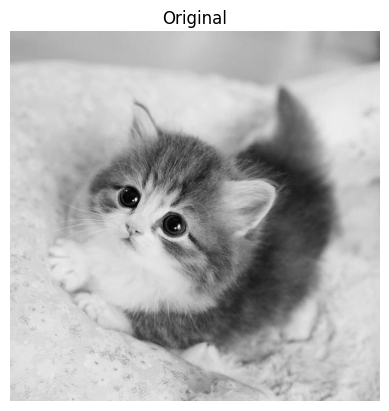

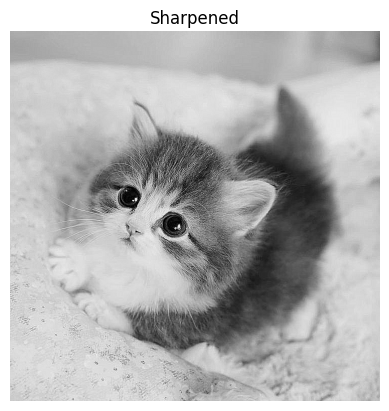

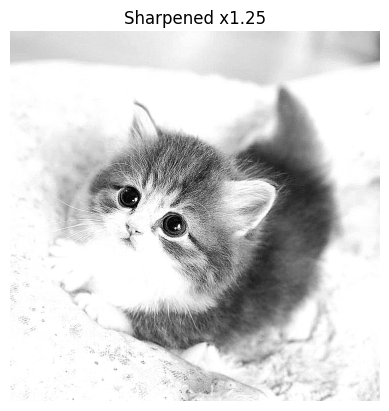

In [ ]:
# Ядро для повышения резкости
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5,-1],
    [0, -1, 0]
])

# Степень повышения резкости
alpha = 1.25

 # Применение свертки
sharpened_1 = convolve2d(gray, sharpen_kernel)
sharpened_1 = np.clip(sharpened_1, 0, 255).astype(np.uint8)

sharpened_2 = convolve2d(gray, sharpen_kernel * alpha)
sharpened_2 = np.clip(sharpened_2, 0, 255).astype(np.uint8)

# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

plt.imshow(sharpened_1, cmap="gray")
plt.title("Sharpened")
plt.axis("off")
plt.show()

plt.imshow(sharpened_2, cmap="gray")
plt.title("Sharpened x1.25")
plt.axis("off")
plt.show()

#### Детектор границ

In [ ]:
# горизонтальный детектор границ
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# вертикальный детектор границ
sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])  


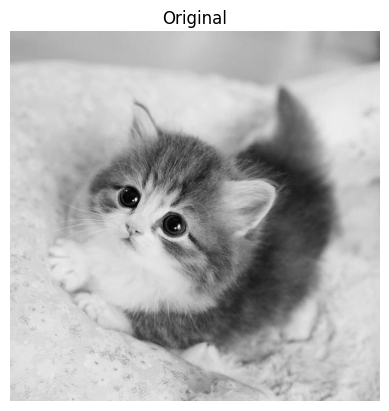

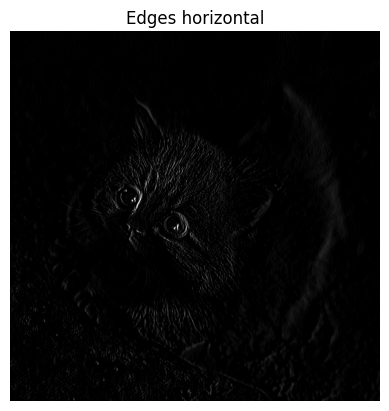

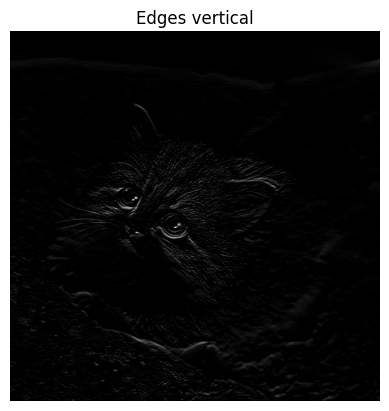

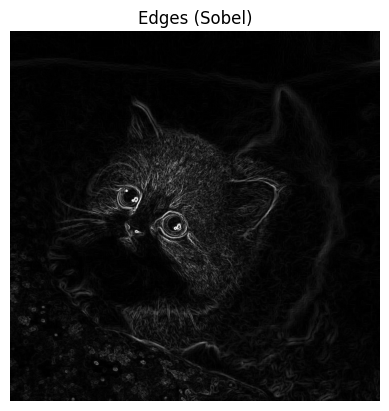

In [ ]:
alpha = 0.5 # коэффициент усиления границ

gx = convolve2d(gray, sobel_x*alpha)
gy = convolve2d(gray, sobel_y*alpha)

edges = np.sqrt(gx**2 + gy**2)
edges = np.clip(edges, 0, 255).astype(np.uint8)

horizontal_edges = np.clip(gx, 0, 255).astype(np.uint8)
vertical_edges = np.clip(gy, 0, 255).astype(np.uint8)

# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

plt.imshow(horizontal_edges, cmap="gray")
plt.title("Edges horizontal")
plt.axis("off")
plt.show()

plt.imshow(vertical_edges, cmap="gray")
plt.title("Edges vertical")
plt.axis("off")
plt.show()

plt.imshow(edges, cmap="gray")
plt.title("Edges (Sobel)")
plt.axis("off")
plt.show()

#### Усиление яркости

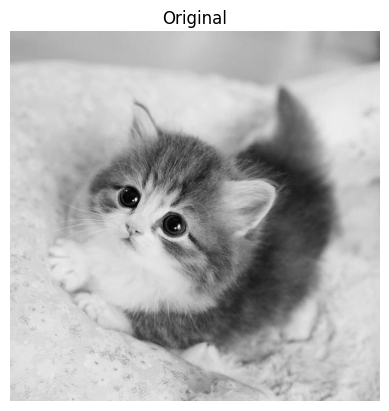

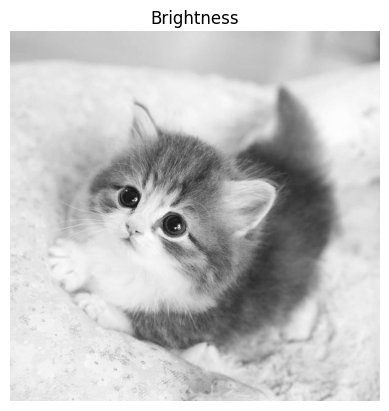

In [ ]:
brightness = np.clip(gray + 20, 0, 255)

# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

plt.imshow(brightness, cmap="gray")
plt.title('Brightness')
plt.axis("off")
plt.show()


#### Бинаризация

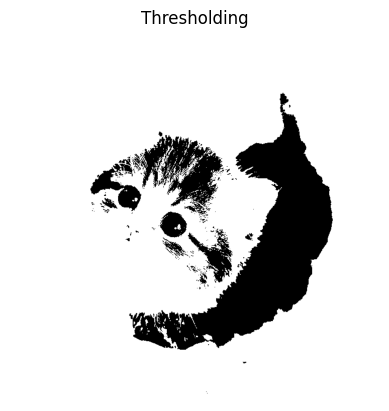

In [ ]:
threshold = 100
binary = (gray > threshold)*255
binary = binary.astype(np.uint8)

plt.imshow(binary, cmap="gray")
plt.title("Thresholding")
plt.axis("off")
plt.show()


#### Медианный фильтр

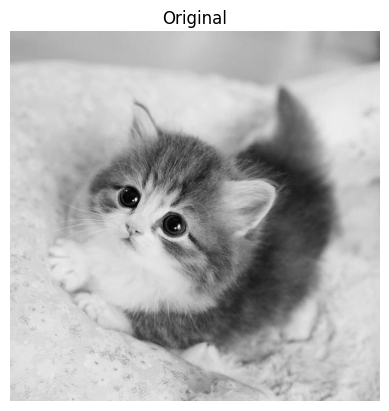

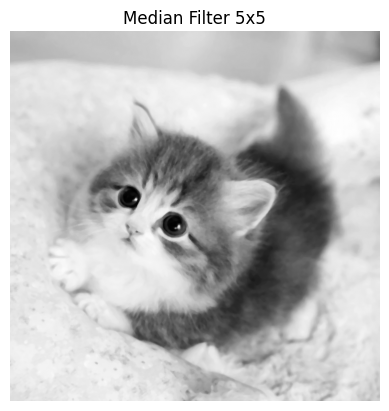

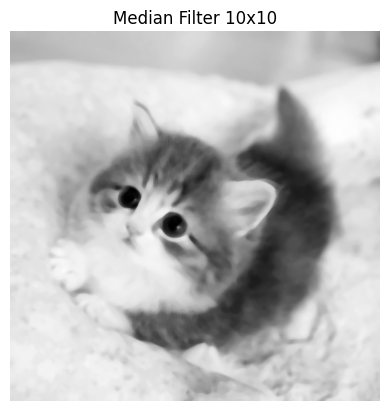

In [ ]:
def median_filter_gray(image, ksize=3):
    H, W = image.shape
    pad = ksize // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')
    output = np.zeros_like(image)
    
    for i in range(H):
        for j in range(W):
            region = padded[i:i+ksize, j:j+ksize]
            output[i, j] = np.median(region)
    return output


# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

median_img = median_filter_gray(gray, ksize=5)
plt.imshow(median_img, cmap="gray")
plt.title("Median Filter 5x5")
plt.axis("off")
plt.show()

median_img = median_filter_gray(gray, ksize=10)
plt.imshow(median_img, cmap="gray")
plt.title("Median Filter 10x10")
plt.axis("off")
plt.show()

#### Эффект тиснения

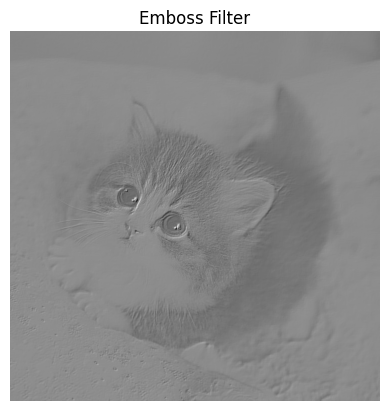

In [ ]:
# Emboss
emboss_kernel = np.array([
    [-2,-1,0],
    [-1,1,1],
    [0,1,2]
])

emboss_img = convolve2d(gray, emboss_kernel)
plt.imshow(emboss_img, cmap="gray")
plt.title("Emboss Filter")
plt.axis("off")
plt.show()

#### Негативный фильтр

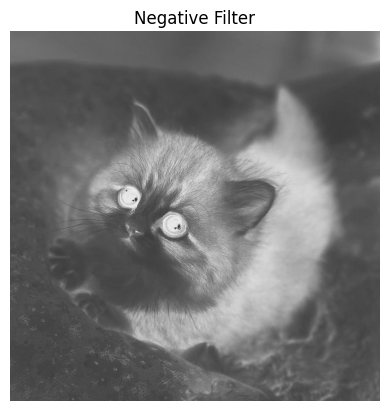

In [ ]:
negative_kernel = np.array([
    [0,1,0],
    [1,-10,1],
    [0,1,0]
])

negative_img = convolve2d(gray, negative_kernel)
plt.imshow(negative_img, cmap="gray")
plt.title("Negative Filter")
plt.axis("off")
plt.show()

#### Фильтр Гаусса

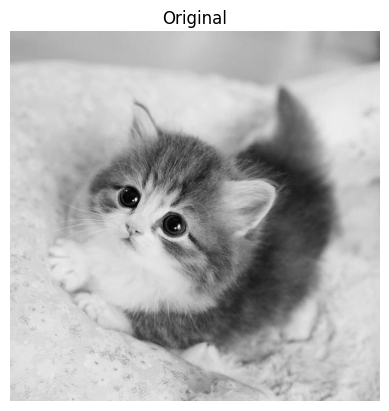

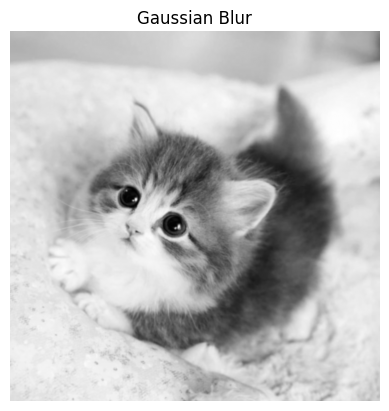

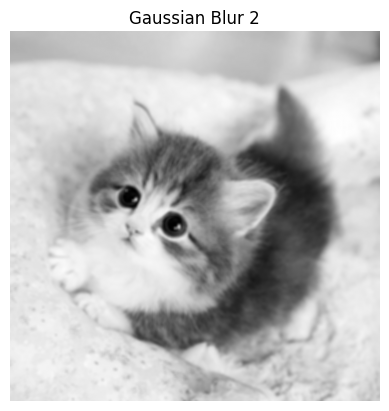

In [ ]:
def gaussian_kernel(size, sigma=1.0):
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel


# Отображение результата
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

gauss_kernel = gaussian_kernel(size=5, sigma=1)
gauss_img = convolve2d(gray, gauss_kernel)
plt.imshow(gauss_img, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

gauss_kernel_3 = gaussian_kernel(size=7, sigma=3)
gauss_img_3 = convolve2d(gray, gauss_kernel_3)
plt.imshow(gauss_img_3, cmap="gray")
plt.title("Gaussian Blur 2")
plt.axis("off")
plt.show()

### Вывод

В ходе работы была изучена и реализована ручная обработка изображений с использованием библиотеки NumPy. Основные результаты:

- *Преобразование в grayscale*
<br>
Изучено, как цветное изображение преобразуется в чёрно-белое с помощью взвешенной суммы каналов R, G, B, учитывая чувствительность человеческого глаза. Это позволяет работать с изображением как с матрицей яркости.

- *Median Filter 3×3*
<br>
Реализован фильтр медианы без использования готовых функций. Фильтр эффективно подавляет шум (например, salt & pepper), сохраняя при этом края объектов.


- *Emboss:* создан эффект тиснения, который подчёркивает границы и создаёт ощущение объёма.


- *Gaussian Blur:* через функцию gaussian_kernel реализовано плавное размытие изображения с регулируемым размером ядра и σ, что позволяет уменьшать шум и смягчать детали.


**Практический вывод**

Свёртка с различными ядрами позволяет гибко управлять визуальными эффектами: усиление границ, размытие, тиснение и др.

Использование NumPy позволяет реализовывать все операции векторизованно и эффективно, без необходимости сторонних библиотек для фильтрации.
